### Problem Statement
"Analyze the toy sales data from various tables (Sales, Stores, Products, Inventory, and Calendar) to derive insights regarding sales performance, inventory levels, product profitability, and store effectiveness in Mexico. The project aims to identify trends in consumer preferences and sales patterns, allowing for strategic recommendations that enhance inventory management, marketing efforts, and sales strategies within the retail environment."

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df_sales = pd.read_csv("Maven+Toys/Maven Toys Data/sales.csv")
df_sales.head(3)

,Sale_ID,Date,Store_ID,Product_ID,Units
0,1,2022-01-01,24,4,1
1,2,2022-01-01,28,1,1
2,3,2022-01-01,6,8,1


In [3]:
df_stores = pd.read_csv("Maven+Toys/Maven Toys Data/stores.csv")
df_stores.head(3)

,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18
1,2,Maven Toys Monterrey 1,Monterrey,Residential,1995-04-27
2,3,Maven Toys Guadalajara 2,Guadalajara,Commercial,1999-12-27


In [4]:
df_products = pd.read_csv("Maven+Toys/Maven Toys Data/products.csv")
df_products.head(3)

,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,Action Figure,Toys,$9.99,$15.99
1,2,Animal Figures,Toys,$9.99,$12.99
2,3,Barrel O' Slime,Art & Crafts,$1.99,$3.99


In [5]:
df_inventory = pd.read_csv("Maven+Toys/Maven Toys Data/inventory.csv")
df_calender = pd.read_csv("Maven+Toys/Maven Toys Data/calendar.csv")

In [6]:
print(df_sales.shape)
print(df_stores.shape)
print(df_products.shape)
print(df_inventory.shape)
print(df_calender.shape)

(829262, 5)
(50, 5)
(35, 5)
(1593, 3)
(638, 1)


In [7]:
#null values check
df_sales.isnull().sum()

Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64

In [8]:
df_stores.isnull().sum()

Store_ID           0
Store_Name         0
Store_City         0
Store_Location     0
Store_Open_Date    0
dtype: int64

In [9]:
df_products.isnull().sum()

Product_ID          0
Product_Name        0
Product_Category    0
Product_Cost        0
Product_Price       0
dtype: int64

In [10]:
df_inventory.isnull().sum()

Store_ID         0
Product_ID       0
Stock_On_Hand    0
dtype: int64

In [11]:
df_calender.isnull().sum()

Date    0
dtype: int64

In [12]:
# DATA CLEANING AND WRANGLING

#merge sales with stores
df = df_sales.merge(df_stores, how='left',left_on='Store_ID',right_on='Store_ID')
df.head(3)

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13


In [13]:
#merge with products
df = df.merge(df_products, how='left',left_on='Product_ID',right_on='Product_ID')
df.head(3)

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99


In [14]:
df = df.merge(df_calender, how='left',left_on='Date',right_on='Date')
df.head(3)

,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Name,Store_City,Store_Location,Store_Open_Date,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,$3.99,$6.99


In [15]:
#convert all column names to lowercase letters
df.columns = df.columns.str.lower()
df.columns.values

array(['sale_id', 'date', 'store_id', 'product_id', 'units', 'store_name',
       'store_city', 'store_location', 'store_open_date', 'product_name',
       'product_category', 'product_cost', 'product_price'], dtype=object)

In [16]:
df[['Amount','Currency']] = df['product_cost'].str.split('$', expand=True)

In [17]:
df.head(2)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,product_cost,product_price,Amount,Currency
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$9.99,$12.99,,9.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$9.99,$15.99,,9.99


In [18]:
df = df.drop(['product_cost','Amount'], axis=1)
df.head(2)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,product_price,Currency
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$12.99,9.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$15.99,9.99


In [19]:
df[['amount_price','Currency_price']] = df['product_price'].str.split('$', expand=True)

In [20]:
df.head(2)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,product_price,Currency,amount_price,Currency_price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,$12.99,9.99,,12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,$15.99,9.99,,15.99


In [21]:
df = df.drop(['product_price','amount_price'], axis=1)
df.head(2)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,Currency,Currency_price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99


In [22]:
df.rename(columns={'Currency': 'product_cost'}, inplace=True)
df.rename(columns={'Currency_price': 'product_price'}, inplace=True)

In [23]:
df.head(3)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,product_cost,product_price
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99


In [24]:
df['revenue'] = df['units'] * df['product_price']
df['total_cost'] = df['units'] * df['product_cost']

In [25]:
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['total_cost'] = pd.to_numeric(df['total_cost'], errors='coerce')

In [26]:
df['profit'] = df['revenue'] - df['total_cost']

In [27]:
df.head(3)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,product_cost,product_price,revenue,total_cost,profit
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99,12.99,9.99,3.0
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99,15.99,9.99,6.0
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99,6.99,3.99,3.0


In [28]:
df['profit_margin'] = (df['profit'] / df['revenue']) * 100
df['profit_margin_%'] = df['profit_margin'].round(0).astype(str) + '%'
df.head(2)

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,product_category,product_cost,product_price,revenue,total_cost,profit,profit_margin,profit_margin_%
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99,12.99,9.99,3.0,23.094688,23.0%
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99,15.99,9.99,6.0,37.523452,38.0%


### EDA

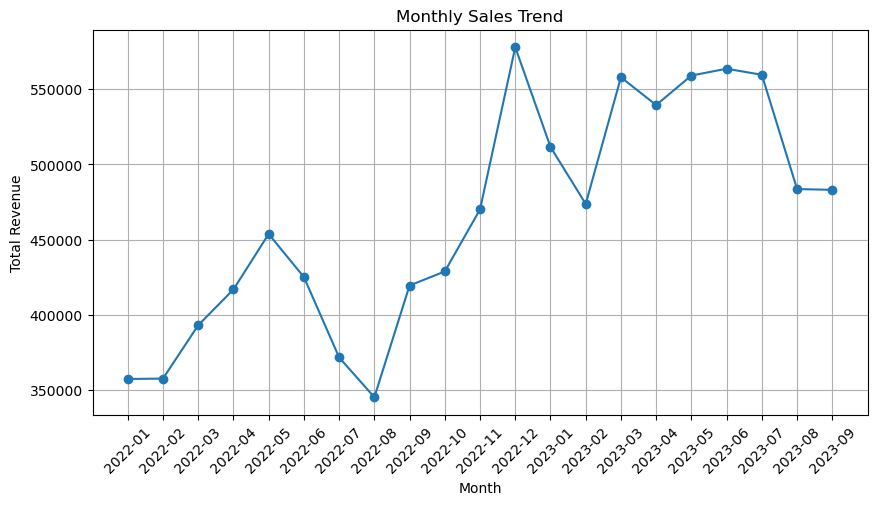

In [29]:
#time series analysis - plotting a line chart

# convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# create a month column (Year-Month format)
df['month'] = df['date'].dt.to_period('M')

# aggregate monthly sales (using revenue)
monthly_sales = df.groupby('month')['revenue'].sum().reset_index()

# convert month back to timestamp for plotting
monthly_sales['month'] = monthly_sales['month'].astype(str)

# plot line chart
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['month'], monthly_sales['revenue'], marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.show() 

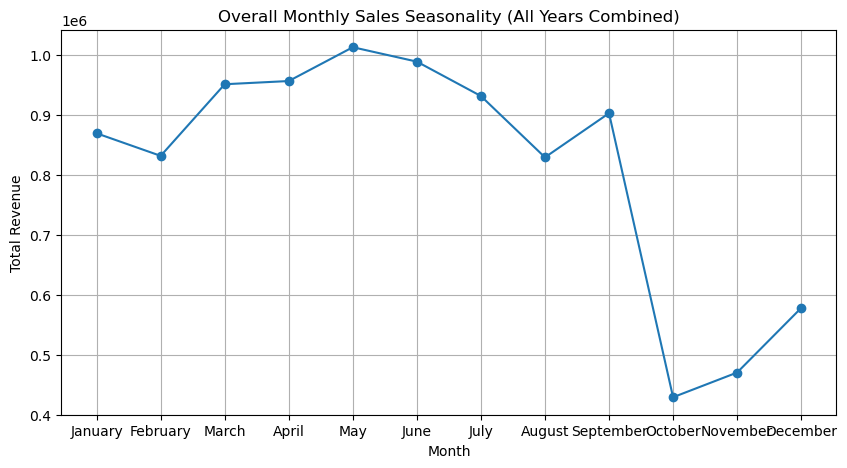

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# extract month number and month name
df['month_num'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

# aggregate revenue by calendar month across all years
monthly_seasonality = df.groupby(['month_num','month_name'])['revenue'].sum().reset_index()

# sort months in correct order
monthly_seasonality = monthly_seasonality.sort_values('month_num')

# plot the seasonality trend
plt.figure(figsize=(10,5))
plt.plot(monthly_seasonality['month_name'], monthly_seasonality['revenue'], marker='o')

plt.title('Overall Monthly Sales Seasonality (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)

plt.show()

In [32]:
df.to_csv("final.csv")

In [34]:
df.isnull().sum()

sale_id                  0
date                     0
store_id                 0
product_id               0
units                    0
store_name               0
store_city               0
store_location           0
store_open_date          0
product_name             0
product_category         0
product_cost             0
product_price            0
revenue             140239
total_cost          140239
profit              140239
profit_margin       140239
profit_margin_%          0
month                    0
month_num                0
month_name               0
dtype: int64

In [42]:
df.to_csv("final_new.csv")

In [46]:
df = df.drop(['revenue','total_cost','profit','profit_margin','profit_margin_%'], axis=1)

In [48]:
df.dtypes

sale_id                      int64
date                datetime64[ns]
store_id                     int64
product_id                   int64
units                        int64
store_name                  object
store_city                  object
store_location              object
store_open_date             object
product_name                object
product_category            object
product_cost                object
product_price               object
month                    period[M]
month_num                    int32
month_name                  object
dtype: object

In [49]:
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')
df['product_cost'] = pd.to_numeric(df['product_cost'], errors='coerce')

In [50]:
df['revenue'] = df['units'] * df['product_price']
df['total_cost'] = df['units'] * df['product_cost']
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin'] = df['profit'] / df['revenue']

In [61]:
df['profit_margin_%'] = ((df['profit'] / df['revenue']) * 100).round(2).astype(str) + '%' 

In [62]:
df.head()

,sale_id,date,store_id,product_id,units,store_name,store_city,store_location,store_open_date,product_name,...,product_cost,product_price,month,month_num,month_name,revenue,total_cost,profit,profit_margin,profit_margin_%
0,1,2022-01-01,24,4,1,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,...,9.99,12.99,2022-01,1,January,12.99,9.99,3.0,0.230947,23.09%
1,2,2022-01-01,28,1,1,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,...,9.99,15.99,2022-01,1,January,15.99,9.99,6.0,0.375235,37.52%
2,3,2022-01-01,6,8,1,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,...,3.99,6.99,2022-01,1,January,6.99,3.99,3.0,0.429185,42.92%
3,4,2022-01-01,48,7,1,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,...,11.99,15.99,2022-01,1,January,15.99,11.99,4.0,0.250156,25.02%
4,5,2022-01-01,44,18,1,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,...,34.99,39.99,2022-01,1,January,39.99,34.99,5.0,0.125031,12.5%


In [64]:
df.to_csv('final_final.csv')

In [65]:
df['sale_year'] = df['date'].dt.year

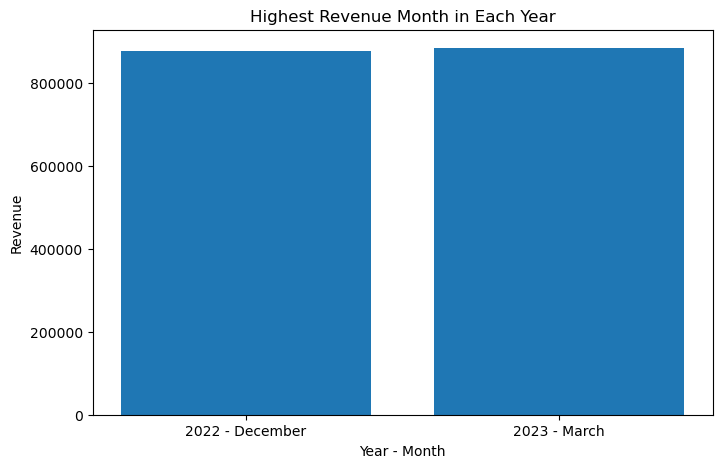

In [72]:
monthly_revenue = df.groupby(['sale_year','month_num','month_name'])['revenue'].sum().reset_index()
max_months = monthly_revenue.loc[monthly_revenue.groupby('sale_year')['revenue'].idxmax()]
plt.figure(figsize=(8,5))

plt.bar(max_months['sale_year'].astype(str) + " - " + max_months['month_name'],
        max_months['revenue'])

plt.title('Highest Revenue Month in Each Year')
plt.xlabel('Year - Month')
plt.ylabel('Revenue')

plt.show()

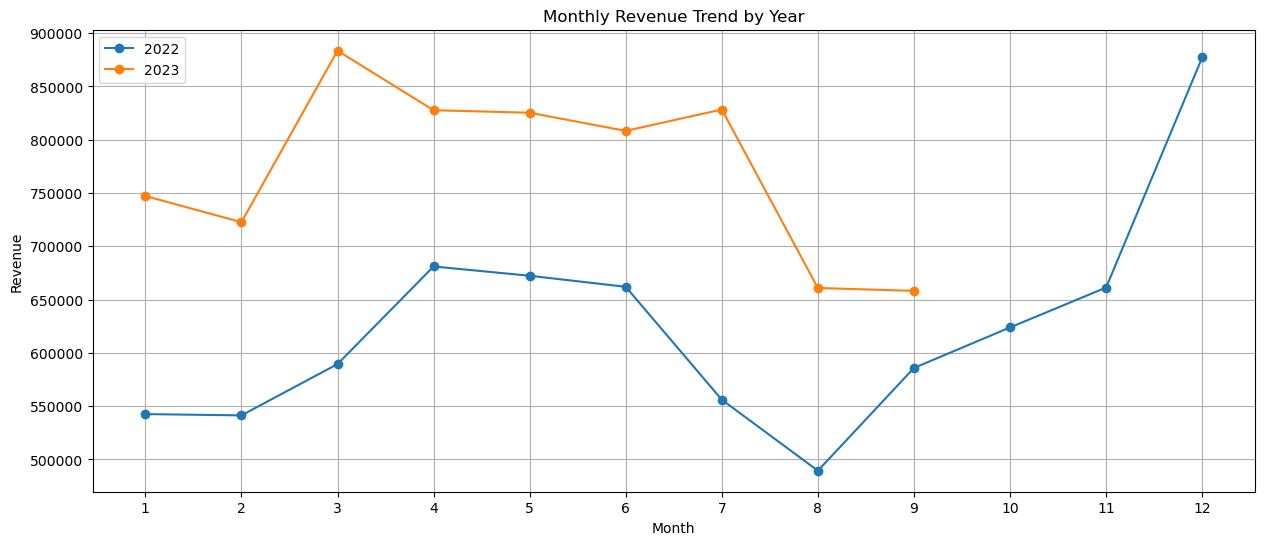

In [78]:
monthly_sales = df.groupby(['sale_year','month_num','month_name'])['revenue'].sum().reset_index()

plt.figure(figsize=(15,6))

for year in monthly_sales['sale_year'].unique():
    data = monthly_sales[monthly_sales['sale_year'] == year]
    plt.plot(data['month_num'], data['revenue'], marker='o', label=year)

plt.title('Monthly Revenue Trend by Year')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1,13))

plt.legend()
plt.grid(True)

plt.show()

In [79]:
# top 10 products by revenue
top_products = df.groupby('product_name')['revenue'].sum().reset_index()
top_products = top_products.sort_values(by='revenue', ascending=False)
top_10_products = top_products.head(10)

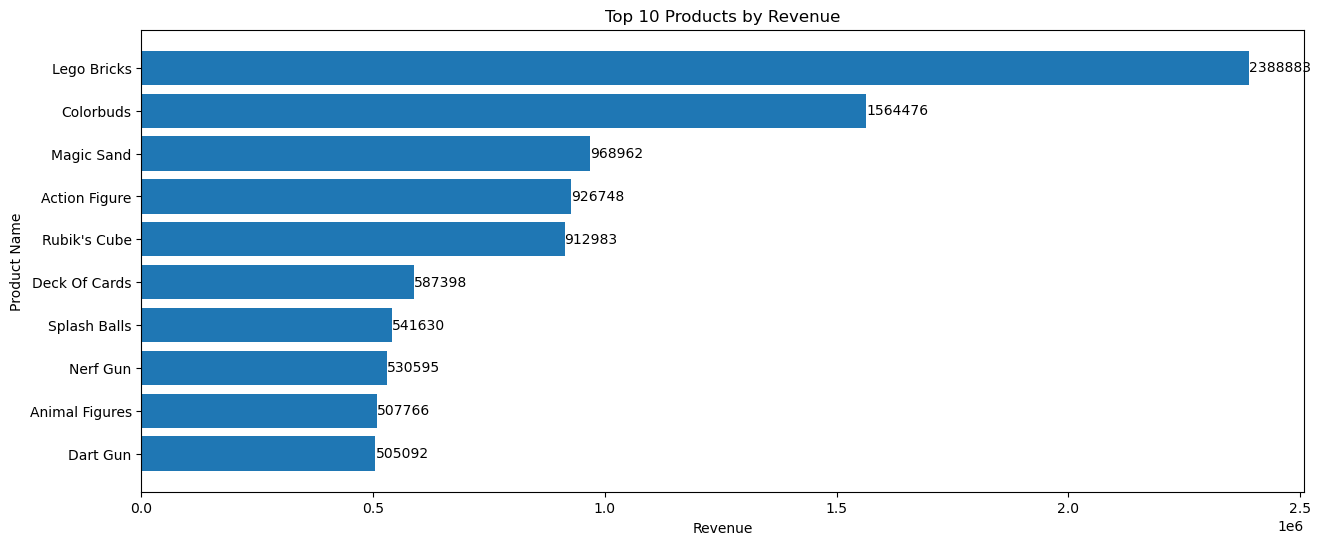

In [91]:
plt.figure(figsize=(15,6))

bars=plt.barh(top_10_products['product_name'], top_10_products['revenue'])

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Name')

plt.gca().invert_yaxis()
plt.bar_label(bars, fmt='%.0f')
plt.show()

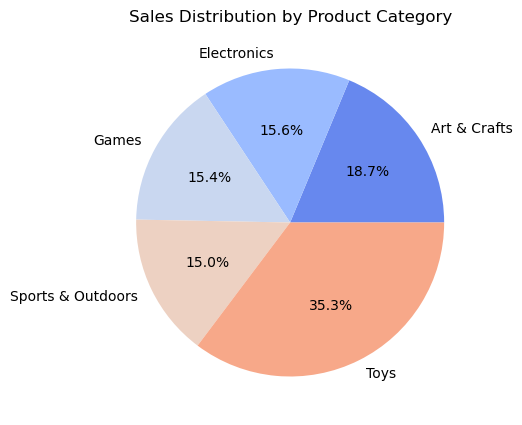

In [98]:
# SALES BY PRODUCT CATEGORY
category_sales = df.groupby('product_category')['revenue'].sum().reset_index()
plt.figure(figsize=(5,5))

plt.pie(category_sales['revenue'],
        labels=category_sales['product_category'],
        colors=sns.color_palette('coolwarm'),
        autopct='%1.1f%%')

plt.title('Sales Distribution by Product Category')

plt.show()

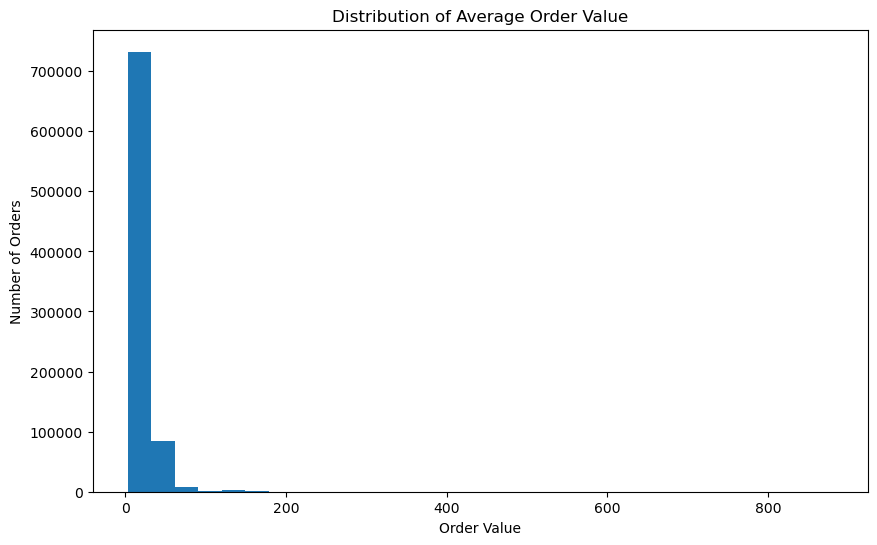

In [111]:
# average order value
order_value = df.groupby('sale_id')['revenue'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.hist(order_value['revenue'], bins=30)
plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')

plt.show()

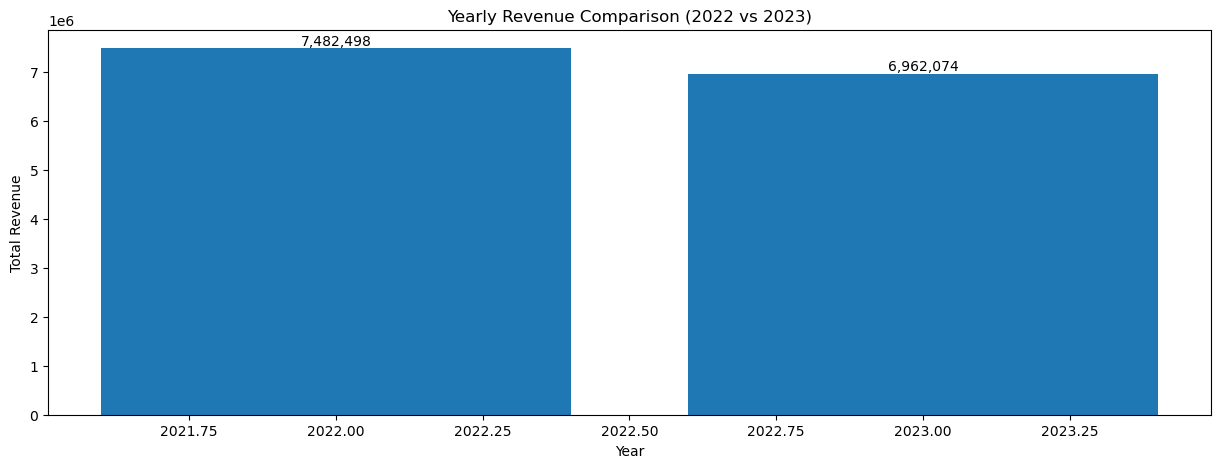

In [112]:
#yearly sales trend (2022 vs 2023)
yearly_revenue = df.groupby('sale_year')['revenue'].sum().reset_index()
plt.figure(figsize=(15,5))

bars = plt.bar(yearly_revenue['sale_year'], yearly_revenue['revenue'])

plt.title('Yearly Revenue Comparison (2022 vs 2023)')
plt.xlabel('Year')
plt.ylabel('Total Revenue')

plt.bar_label(bars, fmt='{:,.0f}')

plt.show()

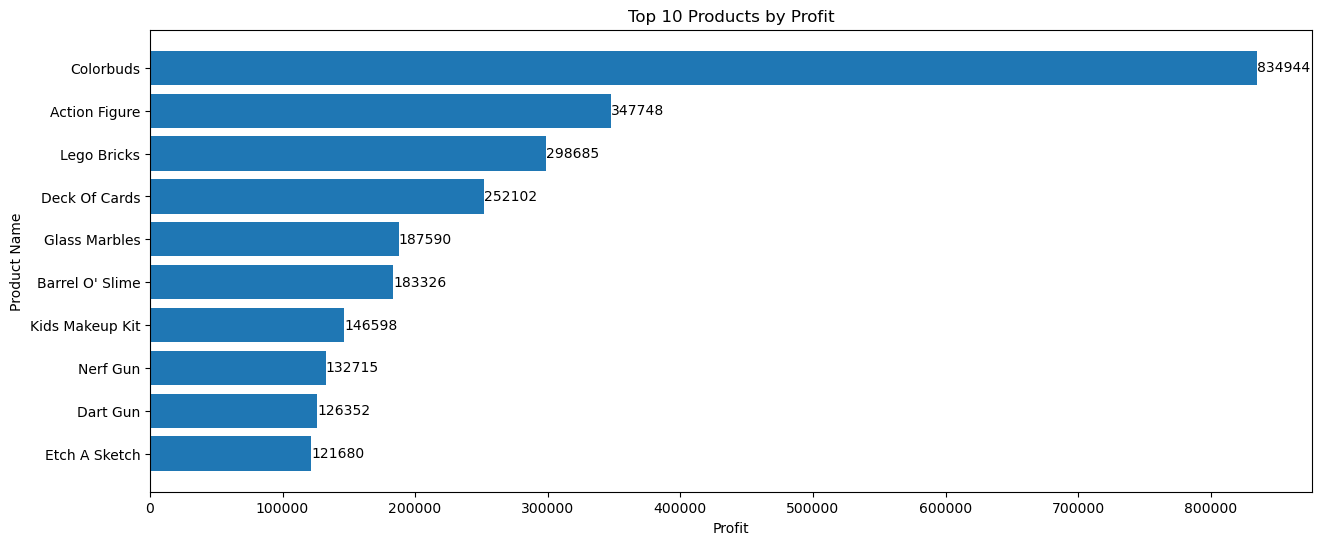

In [119]:
#Top 10 Products by Profit
top_products_by_profit = df.groupby('product_name')['profit'].sum().reset_index()
top_products_by_profit = top_products_by_profit.sort_values(by='profit', ascending=False)
top_10_products_by_profit = top_products_by_profit.head(10)

plt.figure(figsize=(15,6))

bars=plt.barh(top_10_products_by_profit['product_name'], top_10_products_by_profit['profit'])

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product Name')

plt.gca().invert_yaxis()
plt.bar_label(bars, fmt='%.0f')
plt.show()

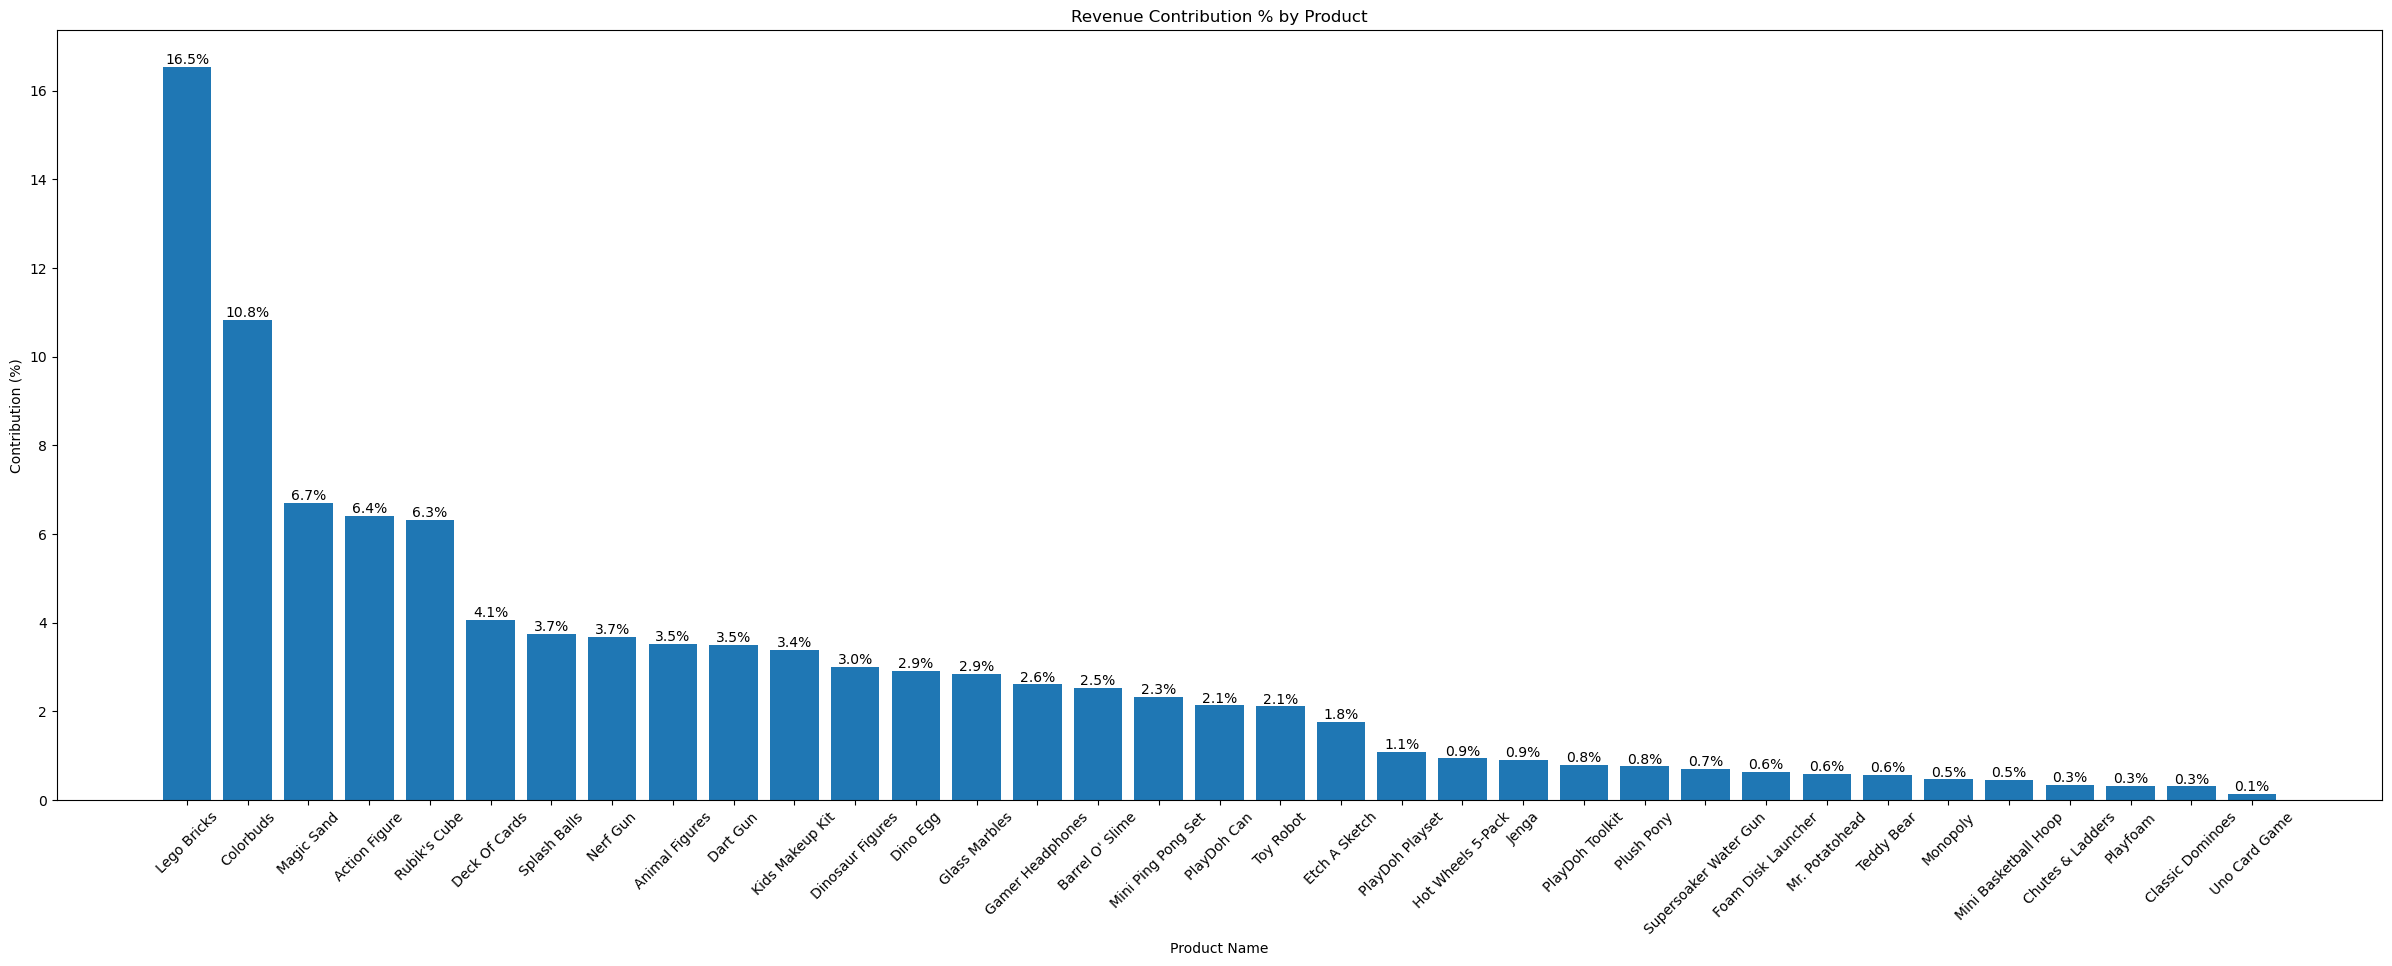

In [132]:
# Revenue Contribution % by Product
product_revenue = df.groupby('product_name')['revenue'].sum().reset_index()
total_revenue = product_revenue['revenue'].sum()
product_revenue['revenue_contribution_%'] = (product_revenue['revenue'] / total_revenue) * 100
top_products = product_revenue.sort_values(by='revenue', ascending=False)
plt.figure(figsize=(30,10))

bars = plt.bar(top_products['product_name'], top_products['revenue_contribution_%'])

plt.title('Revenue Contribution % by Product')
plt.xlabel('Product Name')
plt.ylabel('Contribution (%)')

plt.xticks(rotation=45)

plt.bar_label(bars, fmt='%.1f%%')

plt.show()

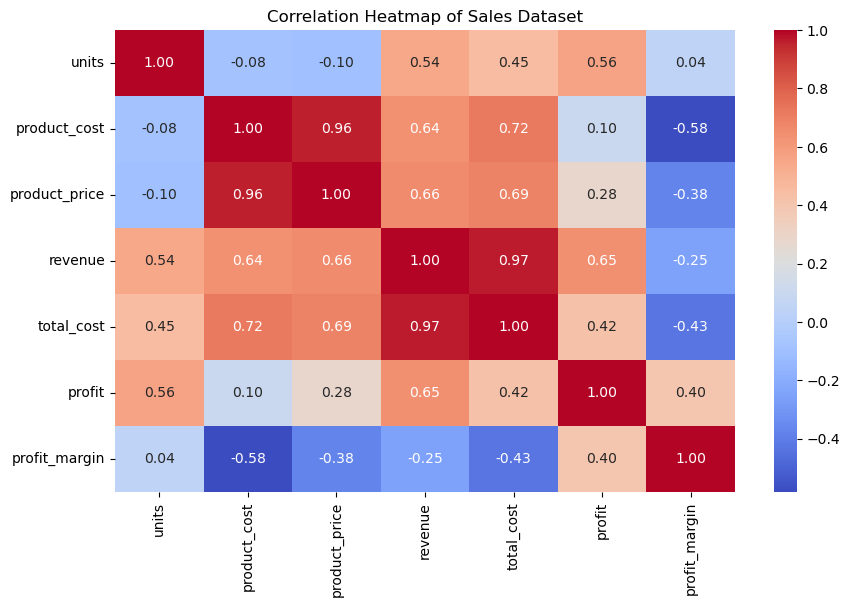

In [133]:
# correlation heatmap
numeric_cols = df[['units','product_cost','product_price','revenue',
                   'total_cost','profit','profit_margin']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap of Sales Dataset')

plt.show()

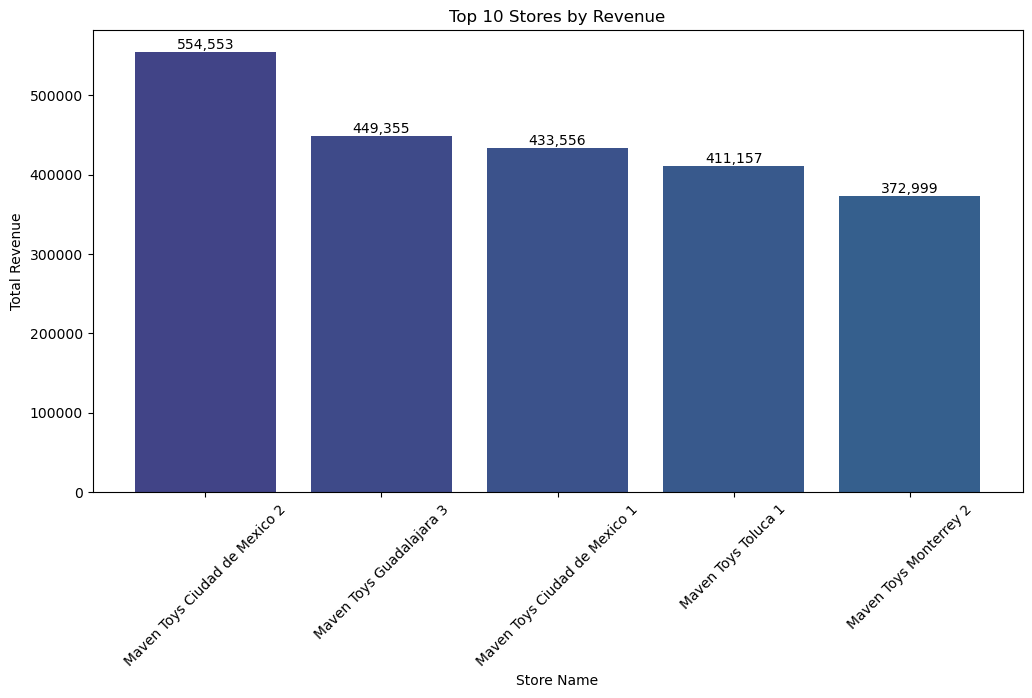

In [166]:
# TOP 10 STORES BY REVENUE
store_revenue = df.groupby('store_name')['revenue'].sum().reset_index()
store_revenue = store_revenue.sort_values(by='revenue', ascending=False)
top_stores = store_revenue.head(5)

plt.figure(figsize=(12,6))

# Create gradient colors
colors = plt.cm.viridis(np.linspace(0.2,0.9,len(city_sales)))

bars = plt.bar(top_stores['store_name'], top_stores['revenue'],color=colors)

plt.title('Top 10 Stores by Revenue')
plt.xlabel('Store Name')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.bar_label(bars, fmt='{:,.0f}')

plt.show()

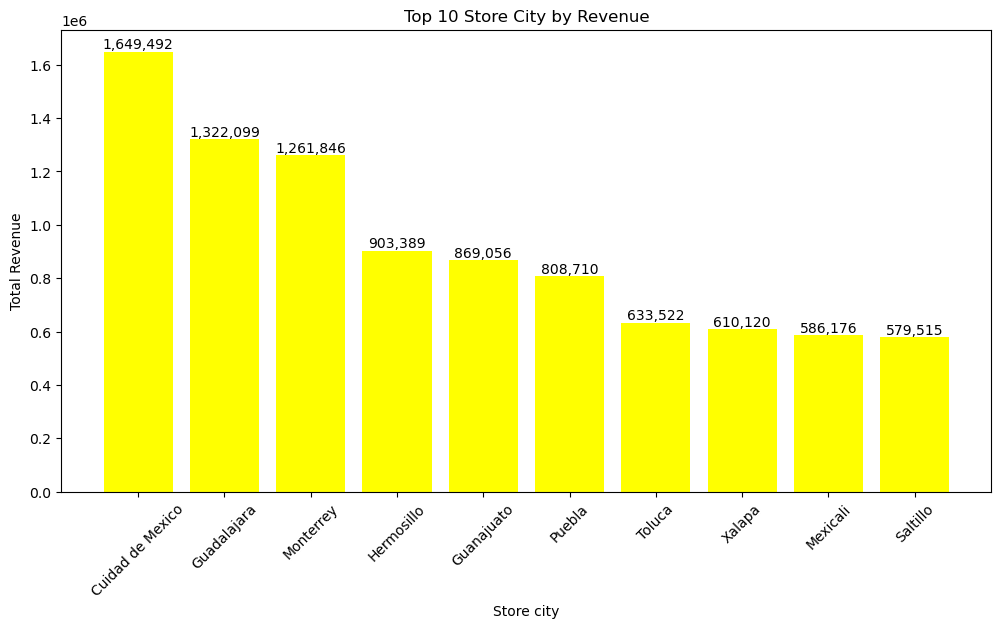

In [163]:
# TOP 7 STORE cities
store_cities = df.groupby('store_city')['revenue'].sum().reset_index()
store_cities = store_cities.sort_values(by='revenue', ascending=False)
top_stores = store_cities.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(top_stores['store_city'], top_stores['revenue'],color="yellow")

plt.title('Top 10 Store City by Revenue')
plt.xlabel('Store city')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.bar_label(bars, fmt='{:,.0f}')

plt.show()

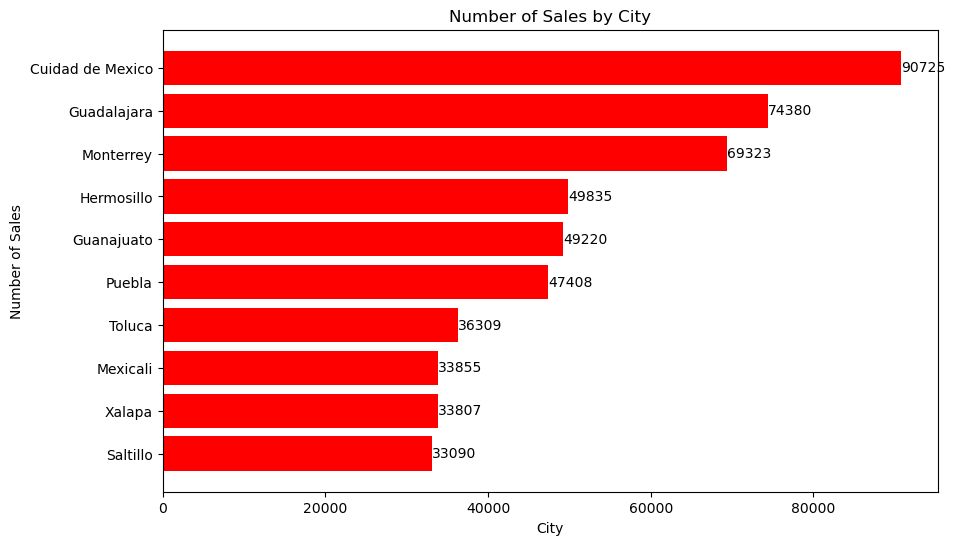

In [159]:
# number of sales by city (top 10 cities with highest number of sales)
city_sales = df.groupby('store_city')['sale_id'].count().reset_index()
city_sales = city_sales.rename(columns={'sale_id':'number_of_sales'})
city_sales = city_sales.sort_values(by='number_of_sales', ascending=False)
top_stores = city_sales.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(top_stores['store_city'], top_stores['number_of_sales'],color="red")

plt.title('Number of Sales by City')
plt.xlabel('City')
plt.ylabel('Number of Sales')

plt.bar_label(bars)
plt.gca().invert_yaxis()
plt.show()

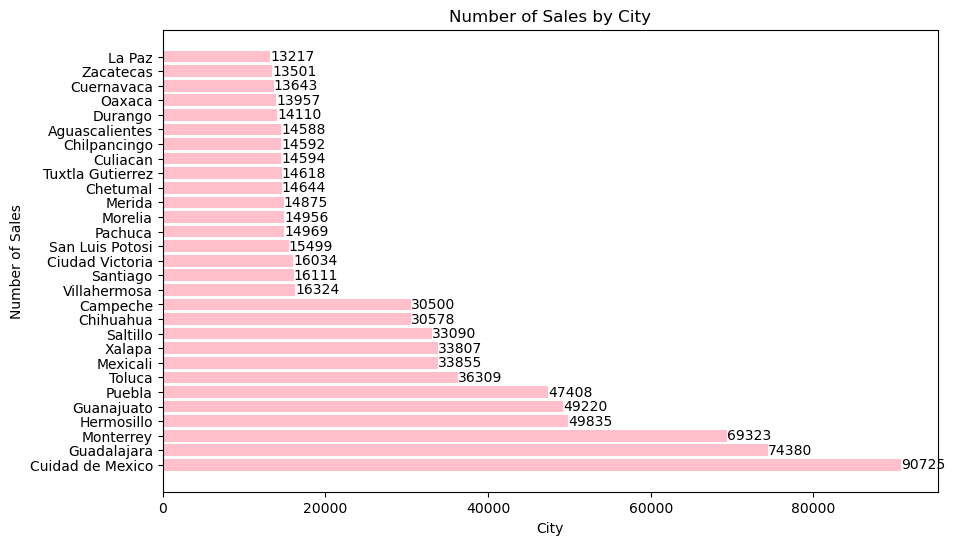

In [162]:
# number of sales by city (all cities with number of sales)
city_sales = df.groupby('store_city')['sale_id'].count().reset_index()
city_sales = city_sales.rename(columns={'sale_id':'number_of_sales'})
city_sales = city_sales.sort_values(by='number_of_sales', ascending=True)
top_stores = city_sales

plt.figure(figsize=(10,6))

bars = plt.barh(top_stores['store_city'], top_stores['number_of_sales'],color="pink")

plt.title('Number of Sales by City')
plt.xlabel('City')
plt.ylabel('Number of Sales')

plt.bar_label(bars)
plt.gca().invert_yaxis()
plt.show()

In [180]:
#revenue growth rate
revenue_calculate = df.groupby('sale_year')['revenue'].sum().reset_index()
revenue_2022 = revenue_calculate['revenue'][0]
revenue_2023 = revenue_calculate['revenue'][1]
growth_rate = ((revenue_2023 - revenue_2022) / revenue_2022) * 100
print(f"Revenue Growth Rate: {growth_rate:.2f}%")


Revenue Growth Rate: -6.96%
